# Low-density parity-check codes: simulate, decode, threshold

One pass through the repository's fourth problem class. A code is the null
space of a sparse parity-check matrix `H`; decoding it is inference on the
factor graph with one parity factor per row, which is the structure the
other three notebooks' recursions run on (`docs/tex/textbook.tex`,
`sec:ldpc`). The specialised decoder in `snakes_and_ladders.likelihood.ldpc`
is the general `sum_product` of `message_passing` with one number per
message, and this notebook holds it to that general implementation, to
enumeration where enumeration reaches, and to the density-evolution
threshold where it does not.

**Scope.** Measurements at the ticket's 19,998-bit size, the profile that
decides a Rust kernel, and the optimization framing against the samplers are
parts 2 and 3 of #340 and are not built. §6 stops at 996 bits; the
release-gated test in `tests/regression/likelihood/test_ldpc.py` runs the
full-size code.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from snakes_and_ladders.likelihood.ldpc import (
    DecodingAlgorithm,
    decode,
    erasure_threshold,
    exact_decoding,
)
from snakes_and_ladders.likelihood.message_passing import MessageSchedule, sum_product
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.sim.factor_graph import from_parity_check
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.ldpc import (
    BinaryErasureChannel,
    BinaryInputGaussianChannel,
    BinarySymmetricChannel,
    ParityCheck,
    all_zero_transmission,
    encode,
    generator_matrix,
)

TINY, MID_SIZE, LONG = (
    fixture("ldpc", tier).params for tier in ("ci", "stress", "release")
)
COLUMN_WEIGHT, ROW_WEIGHT = TINY.column_weight, TINY.row_weight

## 1. A tiny code, and its factor graph

Gallager's construction stacks `column_weight` bands, each a column
permutation of a block-diagonal band of ones, so every column has three ones
and every row six. The rows of one band sum to the all-ones vector, so the
bands make at least two rows dependent and the dimension `k` exceeds
`n - m`: at 12 bits the rate is well above the design rate `1/2`, which is a
finite-size fact and not a defect.

In [2]:
tiny = TINY.code()
k = generator_matrix(tiny).shape[0]
print(f"n = {tiny.n_bits}, m = {tiny.n_checks}, nonzeros = {tiny.n_edges}")
print(
    f"column weights {sorted(set(tiny.column_weights.tolist()))}, row weights {sorted(set(tiny.row_weights.tolist()))}"
)
print(f"k = n - rank H = {k}, so 2**k = {2**k} codewords at rate {k / tiny.n_bits:.3f}")
print("H =")
print(tiny.dense())
graph = from_parity_check(tiny, np.zeros(tiny.n_bits))
print(
    f"factor graph: {len(graph.variables)} variables, {len(graph.factors)} factors, tree: {graph.is_tree()}"
)

n = 12, m = 6, nonzeros = 36
column weights [3], row weights [6]
k = n - rank H = 8, so 2**k = 256 codewords at rate 0.667
H =
[[1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 1 0 1 0 0 1 1 1 0 1]
 [1 1 0 1 0 1 1 0 0 0 1 0]
 [0 0 1 0 1 1 1 1 0 0 0 1]
 [1 1 0 1 0 0 0 0 1 1 1 0]]
factor graph: 12 variables, 18 factors, tree: False


## 2. Three channels, one interface

Every channel returns the log-likelihood ratio
`L_i = log p(y_i | 0) - log p(y_i | 1)`, positive when the received symbol
favours zero. The symmetric channel has one magnitude, `log((1 - p) / p)`;
the erasure channel is zero or certain, with certainty represented as `±30`
because the decoder forms leave-one-out sums by subtraction; the Gaussian
channel's ratio is `2 y / sigma^2`.

In [3]:
for channel in (
    BinarySymmetricChannel(0.15),
    BinaryErasureChannel(0.4),
    BinaryInputGaussianChannel(1.0),
):
    llr = all_zero_transmission(tiny, channel, np.random.default_rng(1))
    print(f"{type(channel).__name__:28s} {np.round(llr, 2)}")

BinarySymmetricChannel       [ 1.73  1.73 -1.73  1.73  1.73  1.73  1.73  1.73  1.73 -1.73  1.73  1.73]
BinaryErasureChannel         [30. 30.  0. 30.  0. 30. 30. 30. 30.  0. 30. 30.]
BinaryInputGaussianChannel   [ 2.69  3.64  2.66 -0.61  3.81  2.89  0.93  3.16  2.73  2.59  2.06  3.09]


## 3. The decoder, held to the oracles

Three oracles share no code with the decoder. On this loopy 12-bit code
both the decoder and the general damped flooding are the Bethe
approximation, so the check is that they reach the *same* fixed point;
enumeration over the 256 codewords gives the exact posteriors, and the gap
between Bethe and exact is measured, not assumed. On a cycle-free code the
tree schedule and enumeration are exact and the decoder must equal both.

In [4]:
llr = all_zero_transmission(
    tiny, BinarySymmetricChannel(0.15), np.random.default_rng(1)
)
decoded = decode(tiny, llr, early_stop=False, max_iterations=3000, tolerance=1e-12)
general = sum_product(
    from_parity_check(tiny, llr),
    schedule=MessageSchedule.FLOODING,
    tolerance=1e-12,
    max_iterations=3000,
)
general_llr = np.array(
    [
        np.log(general.variable[f"x{i}"][0]) - np.log(general.variable[f"x{i}"][1])
        for i in range(tiny.n_bits)
    ]
)
exact = exact_decoding(tiny, llr)
print(
    f"decoder converged in {decoded.iterations} iterations, general flooding in {general.iterations}"
)
print(
    f"decoder and general posteriors agree within 1e-9: {np.abs(decoded.posterior_llr - general_llr).max() < 1e-9}"
)
print(
    f"Bethe against exact, largest gap in log-odds: {np.abs(decoded.posterior_llr - exact.posterior_llr).max():.3f}"
)
print(
    f"bitwise decision agrees with the exact bitwise MAP on {int((decoded.bits == (exact.posterior_llr < 0)).sum())} of {tiny.n_bits} bits"
)

decoder converged in 52 iterations, general flooding in 41
decoder and general posteriors agree within 1e-9: True
Bethe against exact, largest gap in log-odds: 1.117
bitwise decision agrees with the exact bitwise MAP on 12 of 12 bits


In [5]:
def caterpillar(n_checks: int, degree: int) -> ParityCheck:
    """A cycle-free code: consecutive checks share exactly one bit."""
    n_bits = n_checks * (degree - 1) + 1
    dense = np.zeros((n_checks, n_bits), dtype=np.uint8)
    for j in range(n_checks):
        dense[j, j * (degree - 1) : j * (degree - 1) + degree] = 1
    return ParityCheck.from_dense(dense)


tree = caterpillar(7, 4)
llr = all_zero_transmission(
    tree, BinaryInputGaussianChannel(1.0), np.random.default_rng(2)
)
print(
    f"cycle-free code: n = {tree.n_bits}, m = {tree.n_checks}, tree: {from_parity_check(tree, llr).is_tree()}"
)
exact = exact_decoding(tree, llr)
print(f"enumerated {exact.n_codewords} codewords")
for algorithm in DecodingAlgorithm:
    result = decode(
        tree,
        llr,
        algorithm=algorithm,
        early_stop=False,
        max_iterations=20,
        tolerance=1e-14,
    )
    reference = (
        exact.posterior_llr if algorithm is DecodingAlgorithm.SUM_PRODUCT else None
    )
    if reference is not None:
        print(
            f"{algorithm}: exact posteriors within 1e-12: {np.abs(result.posterior_llr - reference).max() < 1e-12}"
        )
    else:
        print(
            f"{algorithm}: decision is the enumerated ML codeword: {np.array_equal(result.bits, exact.ml_codeword)}"
        )

cycle-free code: n = 22, m = 7, tree: True
enumerated 32768 codewords
sum-product: exact posteriors within 1e-12: True
min-sum: decision is the enumerated ML codeword: True


## 4. A real codeword, and why the zero word suffices

At `n <= 512` Gauss–Jordan elimination over GF(2) gives a systematic
encoder, and `H c = 0` is asserted on every word it returns. Sending a
codeword through the symmetric channel on one noise realization negates the
zero word's ratios exactly where `c_i = 1`; the decoder's updates are odd in
each argument, so its posteriors negate with them and its decision moves by
`c`. That is the identity the all-zero shortcut rests on, checked per
realization rather than argued.

In [6]:
code96 = MID_SIZE.code()
message = np.random.default_rng(4).integers(
    0, 2, size=int(generator_matrix(code96).shape[0])
)
codeword = encode(code96, message)
print(
    f"message bits {message.size}, codeword bits {codeword.size}, weight {int(codeword.sum())}, syndrome zero: {not code96.syndrome(codeword).any()}"
)
channel = BinarySymmetricChannel(0.05)
on_zero = all_zero_transmission(code96, channel, np.random.default_rng(5))
on_codeword = channel.log_likelihood_ratios(codeword, np.random.default_rng(5))
sign = 1.0 - 2.0 * codeword
print(
    f"ratios of the codeword are the zero word's up to sign: {np.array_equal(on_codeword, sign * on_zero)}"
)
zero_decoded, codeword_decoded = decode(code96, on_zero), decode(code96, on_codeword)
print(
    f"posteriors negate exactly: {np.array_equal(codeword_decoded.posterior_llr, sign * zero_decoded.posterior_llr)}"
)
print(
    f"error patterns coincide: {np.array_equal(codeword_decoded.bits ^ codeword, zero_decoded.bits)}"
)
print(
    f"decoded: {zero_decoded.decoded} and {codeword_decoded.decoded}, in {zero_decoded.iterations} and {codeword_decoded.iterations} iterations"
)

message bits 50, codeword bits 96, weight 50, syndrome zero: True
ratios of the codeword are the zero word's up to sign: True
posteriors negate exactly: True
error patterns coincide: True
decoded: True and True, in 9 and 9 iterations


## 5. The 996-bit code against the channel parameter

The nearest multiple of six below 1,000. Bit and block error rates of the
zero word over 20 shared seeds, sum-product first on the symmetric channel,
then both check updates on the Gaussian channel, where min-sum's cheaper
update is the textbook's weaker decoder. The (3,6) ensemble's threshold on
the symmetric channel under belief propagation is `p* = 0.084`.

In [7]:
mid = LONG.code()
SEEDS = range(100, 120)


def error_rates(code, channel, algorithm=DecodingAlgorithm.SUM_PRODUCT):
    """Bit error rate, block error rate and mean iterations of the zero word."""
    bits = blocks = iterations = 0
    for seed in SEEDS:
        result = decode(
            code,
            all_zero_transmission(code, channel, np.random.default_rng(seed)),
            algorithm=algorithm,
        )
        bits += int(result.bits.sum())
        blocks += int(not result.decoded)
        iterations += result.iterations
    return (
        bits / (len(SEEDS) * code.n_bits),
        blocks / len(SEEDS),
        iterations / len(SEEDS),
    )


flips = [0.03, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
bsc = [error_rates(mid, BinarySymmetricChannel(p)) for p in flips]
print("symmetric channel, sum-product")
print("   p     BER      FER   iterations")
for p, (ber, fer, its) in zip(flips, bsc, strict=True):
    print(f"  {p:.2f}  {ber:.5f}  {fer:.2f}  {its:5.1f}")

symmetric channel, sum-product
   p     BER      FER   iterations
  0.03  0.00000  0.00    3.1
  0.05  0.00000  0.00    5.7
  0.06  0.00000  0.00   10.2
  0.07  0.00402  0.10   24.0
  0.08  0.02244  0.35   47.4
  0.09  0.04864  0.65   72.2
  0.10  0.07987  0.95   97.2


In [8]:
sigmas = [0.7, 0.8, 0.9]
print("Gaussian channel")
print("  sigma  algorithm     BER      FER")
for sigma in sigmas:
    for algorithm in DecodingAlgorithm:
        ber, fer, _ = error_rates(mid, BinaryInputGaussianChannel(sigma), algorithm)
        print(f"  {sigma:.1f}    {algorithm:12s} {ber:.5f}  {fer:.2f}")

Gaussian channel
  sigma  algorithm     BER      FER
  0.7    sum-product  0.00000  0.00
  0.7    min-sum      0.00000  0.00
  0.8    sum-product  0.00000  0.00


  0.8    min-sum      0.01737  0.20


  0.9    sum-product  0.06837  0.80


  0.9    min-sum      0.11150  0.95


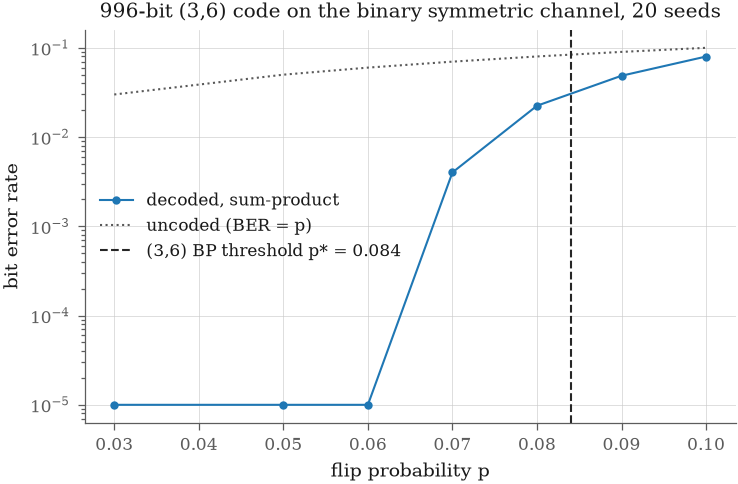

In [9]:
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.6, 3.4))
    axis.plot(
        flips,
        [max(ber, 1e-5) for ber, _, _ in bsc],
        marker="o",
        markersize=3,
        linewidth=1.0,
        label="decoded, sum-product",
    )
    axis.plot(
        flips,
        flips,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="uncoded (BER = p)",
    )
    axis.axvline(
        0.084,
        color="0.15",
        linestyle="--",
        linewidth=1.0,
        label="(3,6) BP threshold p* = 0.084",
    )
    axis.set_yscale("log")
    axis.set_xlabel("flip probability p")
    axis.set_ylabel("bit error rate")
    axis.set_title("996-bit (3,6) code on the binary symmetric channel, 20 seeds")
    axis.legend(frameon=False)
    plt.show()

The waterfall sits below the infinite-length threshold, as a 996-bit member
of the ensemble should: finite length costs rate at fixed error, and the
gap closes as `n` grows.

## 6. Density evolution, and the erasure threshold

On the erasure channel the message-passing decoder's infinite-length
behaviour has a closed form: the erasure probability of a message obeys a
scalar recursion (`app:density-evolution`), and the largest `epsilon` it
drives to zero is the ensemble's threshold. Bisection on that recursion
reproduces the published `0.4294` for (3,6). The 996-bit code is then held
to the *shape* the threshold predicts — every erasure resolved well below
it, most of them surviving well above — rather than to the number itself,
which no code of finite length attains (`sim/CLAUDE.md`).

In [10]:
threshold = erasure_threshold(
    COLUMN_WEIGHT, ROW_WEIGHT, iterations=2000, precision=1e-4
)
print(f"density-evolution threshold for (3,6): {threshold:.4f}")

epsilons = [0.30, 0.35, 0.40, 0.42, 0.44, 0.46, 0.50]
residual = []
for epsilon in epsilons:
    left = []
    for seed in SEEDS:
        llr = all_zero_transmission(
            mid, BinaryErasureChannel(epsilon), np.random.default_rng(seed)
        )
        left.append(
            float(np.mean(decode(mid, llr, max_iterations=300).posterior_llr == 0))
        )
    residual.append(float(np.mean(left)))
print("  epsilon  residual erasure fraction")
for epsilon, fraction in zip(epsilons, residual, strict=True):
    print(f"  {epsilon:.2f}     {fraction:.4f}")

density-evolution threshold for (3,6): 0.4294


  epsilon  residual erasure fraction
  0.30     0.0000
  0.35     0.0000
  0.40     0.0356
  0.42     0.0902
  0.44     0.2352
  0.46     0.3344
  0.50     0.4330


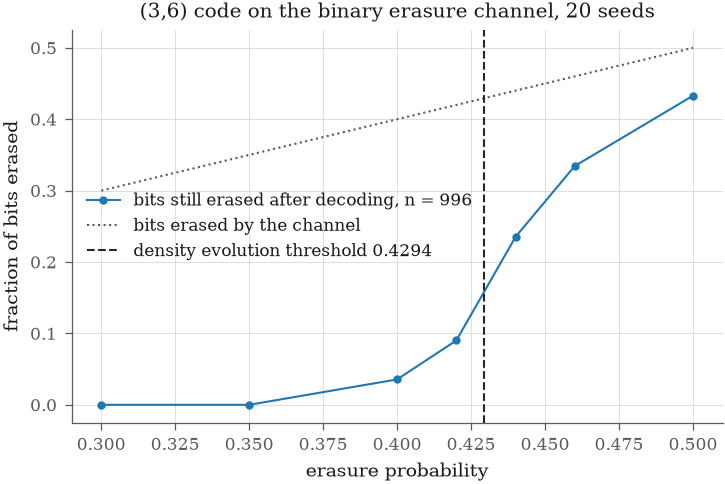

In [11]:
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.6, 3.4))
    axis.plot(
        epsilons,
        residual,
        marker="o",
        markersize=3,
        linewidth=1.0,
        label="bits still erased after decoding, n = 996",
    )
    axis.plot(
        epsilons,
        epsilons,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="bits erased by the channel",
    )
    axis.axvline(
        threshold,
        color="0.15",
        linestyle="--",
        linewidth=1.0,
        label=f"density evolution threshold {threshold:.4f}",
    )
    axis.set_xlabel("erasure probability")
    axis.set_ylabel("fraction of bits erased")
    axis.set_title("(3,6) code on the binary erasure channel, 20 seeds")
    axis.legend(frameon=False)
    plt.show()

## Further work

What this notebook could not demonstrate, because the feature is not built.
Each line names the issue that carries it.

- **The code at size (#340, part 2).** Bit and block error rates against
  `p`, `epsilon` and `sigma` at 19,998 bits over shared seeds, iterations to
  convergence, wall clock and peak memory against the 16 GB requirement, and
  the profile that decides whether a Rust kernel over the same offsets
  follows. §5 and §6 stop at 996 bits; the release gate runs the full-size
  erasure bracket.
- **Decoding as optimization (#340, part 3).** MAP decoding as energy
  minimization under hard parity constraints, compared at matched
  evaluations through `opt.budget` against the Gibbs sampler, the annealer
  and single-site descent on enumerable codes, with the enumerated ML
  codeword as referee.
- **A linear-time encoder (#340).** §4's Gauss–Jordan encoder stops at 512
  bits; past it every simulation sends the zero word on the symmetry
  argument §4 checks.
- **Turbo codes (#233).** A second code family on the same factor-graph
  machinery, with the belief-propagation example the ticket asks for.